# Home Credit: feature selection, feature engineering, and neural networks

Optimize **validation ROC AUC**, then evaluate the held-out test split once.
This notebook compares a raw-feature neural network with engineered-feature
networks, training-only feature selection, and a multi-seed neural-network
ensemble. The result is the best of the experiments run here, not a guarantee
of the mathematical maximum AUC.

Run all cells from the project directory. Dependencies: numpy, pandas, scipy,
scikit-learn, torch, matplotlib, and joblib. This dataset is imbalanced, so
accuracy is not the model-selection objective. CPU execution can take several
minutes; a CUDA GPU is used automatically when available.


In [1]:
import copy
import gc
import json
import math
import os
import random
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import MissingIndicator, SimpleImputer
from sklearn.metrics import (
    average_precision_score, classification_report, confusion_matrix,
    log_loss, roc_auc_score, RocCurveDisplay, PrecisionRecallDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, QuantileTransformer

RANDOM_STATE = 42
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Small matrix batches are often slower with excessive CPU threading.
torch.set_num_threads(1)
ARTIFACT_DIR = Path('nn1_artifacts')
ARTIFACT_DIR.mkdir(exist_ok=True)
MAX_EPOCHS = 40
PATIENCE = 7
BATCH_SIZE = 2048

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(RANDOM_STATE)
print(f'Device: {DEVICE}; PyTorch {torch.__version__}')


Device: cpu; PyTorch 2.14.0+cpu


## 1. Stratified train / validation / test split

Split by `TARGET` using `stratify` in both `train_test_split` calls and
`random_state=42`: **64% training, 16% validation, and 20% test**. Each subset
preserves the approximately 8.07% default rate. The table below verifies class
balance; assertions check that the splits are disjoint and cover every row.

All imputation, quantile transforms, categorical vocabularies, feature rankings,
and neural-network weights use training rows. Validation selects checkpoints,
hyperparameters, and ensemble membership. Test labels are used here only for
stratification and the class-balance audit; test performance is evaluated after
model selection is frozen. This split is held out from the current search;
an earlier project notebook also evaluated this split.


In [2]:
df = pd.read_csv('application_train.csv')
assert df['SK_ID_CURR'].is_unique, 'Repeated applicants need a grouped split.'
assert set(df['TARGET'].unique()) == {0, 1}
train_pool_idx, test_idx = train_test_split(
    np.arange(len(df)), test_size=0.20, stratify=df['TARGET'],
    random_state=RANDOM_STATE,
)
train_idx, val_idx = train_test_split(
    train_pool_idx, test_size=0.20, stratify=df.iloc[train_pool_idx]['TARGET'],
    random_state=RANDOM_STATE,
)
assert not (set(train_idx) & set(val_idx) or set(train_idx) & set(test_idx)
            or set(val_idx) & set(test_idx))
train_raw = df.iloc[train_idx].drop(columns=['TARGET', 'SK_ID_CURR']).copy()
val_raw = df.iloc[val_idx].drop(columns=['TARGET', 'SK_ID_CURR']).copy()
y_train = df.iloc[train_idx]['TARGET'].to_numpy(dtype=np.float32)
y_val = df.iloc[val_idx]['TARGET'].to_numpy(dtype=np.float32)
np.savez_compressed(ARTIFACT_DIR / 'split_indices.npz',
                    train=train_idx, validation=val_idx, test=test_idx)
print(f'Train: {len(train_idx):,}; validation: {len(val_idx):,}; test: {len(test_idx):,}')
print(f'Training positive rate: {y_train.mean():.2%}')

# Both splits use stratify=TARGET, preserving the default/non-default ratio.
split_indices = {'Train': train_idx, 'Validation': val_idx, 'Test': test_idx}
assert np.array_equal(np.sort(np.concatenate(list(split_indices.values()))),
                      np.arange(len(df))), 'Every row must occur in exactly one split.'
split_summary = pd.DataFrame([
    {
        'split': name,
        'rows': len(indices),
        'dataset_percent': 100 * len(indices) / len(df),
        'non_default_count': int(df.iloc[indices]['TARGET'].eq(0).sum()),
        'default_count': int(df.iloc[indices]['TARGET'].eq(1).sum()),
        'default_rate_percent': 100 * df.iloc[indices]['TARGET'].mean(),
    }
    for name, indices in split_indices.items()
]).set_index('split').round(4)
display(split_summary)


Train: 196,806; validation: 49,202; test: 61,503
Training positive rate: 8.07%


,rows,dataset_percent,non_default_count,default_count,default_rate_percent
split,,,,,
Train,196806,63.9997,180918,15888,8.0729
Validation,49202,16.0001,45230,3972,8.0728
Test,61503,20.0003,56538,4965,8.0728


,training_missing_percent
COMMONAREA_MODE,69.837810
COMMONAREA_MEDI,69.837810
COMMONAREA_AVG,69.837810
NONLIVINGAPARTMENTS_MEDI,69.386096
NONLIVINGAPARTMENTS_AVG,69.386096
NONLIVINGAPARTMENTS_MODE,69.386096
FONDKAPREMONT_MODE,68.363769
LIVINGAPARTMENTS_AVG,68.321596
LIVINGAPARTMENTS_MODE,68.321596
LIVINGAPARTMENTS_MEDI,68.321596


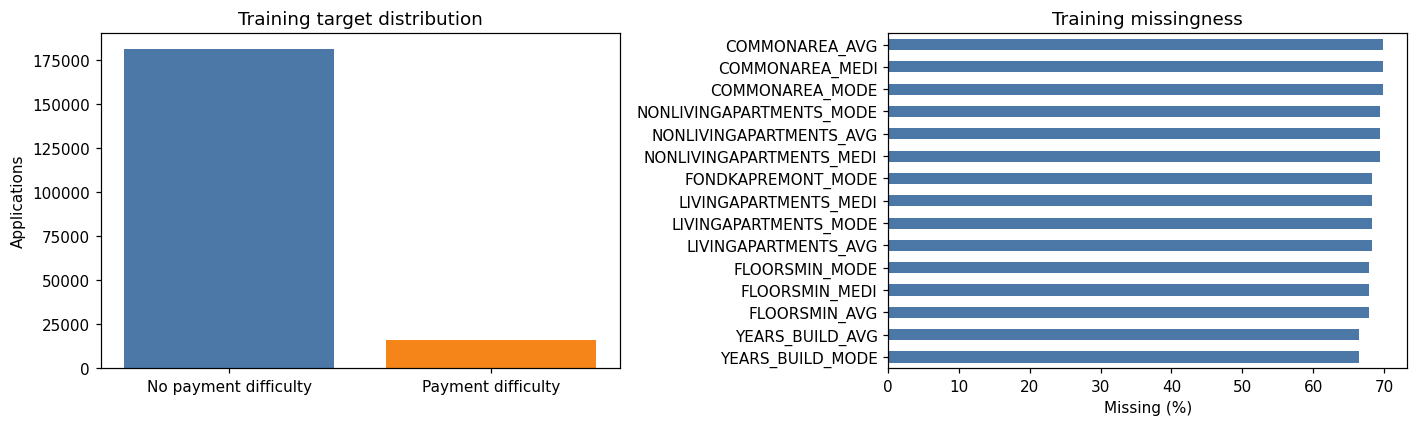

In [3]:
missing_summary = train_raw.isna().mean().mul(100).sort_values(ascending=False)
display(missing_summary.head(15).rename('training_missing_percent').to_frame())
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(['No payment difficulty', 'Payment difficulty'],
            np.bincount(y_train.astype(int)), color=['#4C78A8', '#F58518'])
axes[0].set_title('Training target distribution')
axes[0].set_ylabel('Applications')
missing_summary.head(15).sort_values().plot.barh(ax=axes[1], color='#4C78A8')
axes[1].set_title('Training missingness')
axes[1].set_xlabel('Missing (%)')
plt.tight_layout()
plt.show()


## 2. Engineer application-level features

These calculations are row-local: they do not use labels or statistics from
other applicants. Features capture repayment burden, household resources,
employment history, external-score interactions, and missingness. Ratios use
safe denominators. The unusual employment value `365243` becomes missing and
gets its own indicator. Bureau request windows overlap, so their sum is named
an **activity index**, not a total number of requests.


In [4]:
def safe_divide(numerator, denominator):
    return numerator.div(denominator.replace(0, np.nan))

def engineer_features(raw, engineered=True):
    x = raw.drop(columns=['TARGET', 'SK_ID_CURR'], errors='ignore').copy()
    employment_sentinel = x['DAYS_EMPLOYED'].eq(365243)
    x['DAYS_EMPLOYED'] = x['DAYS_EMPLOYED'].mask(employment_sentinel)
    # XNA is an unknown value in this field, rather than a gender category.
    x['CODE_GENDER'] = x['CODE_GENDER'].replace('XNA', np.nan)
    if not engineered:
        return x.replace([np.inf, -np.inf], np.nan)

    extra = {}
    extra['EMPLOYMENT_UNKNOWN'] = employment_sentinel.astype(float)
    extra['APPLICATION_MISSING_COUNT'] = x.isna().sum(axis=1)
    extra['AGE_YEARS'] = -x['DAYS_BIRTH'] / 365.25
    extra['EMPLOYMENT_YEARS'] = -x['DAYS_EMPLOYED'] / 365.25
    ratios = {
        'CREDIT_TO_INCOME': ('AMT_CREDIT', 'AMT_INCOME_TOTAL'),
        'ANNUITY_TO_INCOME': ('AMT_ANNUITY', 'AMT_INCOME_TOTAL'),
        'CREDIT_TO_ANNUITY': ('AMT_CREDIT', 'AMT_ANNUITY'),
        'ANNUITY_TO_CREDIT': ('AMT_ANNUITY', 'AMT_CREDIT'),
        'GOODS_TO_CREDIT': ('AMT_GOODS_PRICE', 'AMT_CREDIT'),
        'GOODS_TO_INCOME': ('AMT_GOODS_PRICE', 'AMT_INCOME_TOTAL'),
        'INCOME_PER_PERSON': ('AMT_INCOME_TOTAL', 'CNT_FAM_MEMBERS'),
        'CREDIT_PER_PERSON': ('AMT_CREDIT', 'CNT_FAM_MEMBERS'),
        'ANNUITY_PER_PERSON': ('AMT_ANNUITY', 'CNT_FAM_MEMBERS'),
        'CHILDREN_FRACTION': ('CNT_CHILDREN', 'CNT_FAM_MEMBERS'),
        'EMPLOYMENT_TO_AGE': ('DAYS_EMPLOYED', 'DAYS_BIRTH'),
        'REGISTRATION_TO_AGE': ('DAYS_REGISTRATION', 'DAYS_BIRTH'),
        'ID_CHANGE_TO_AGE': ('DAYS_ID_PUBLISH', 'DAYS_BIRTH'),
        'PHONE_CHANGE_TO_AGE': ('DAYS_LAST_PHONE_CHANGE', 'DAYS_BIRTH'),
        'SOCIAL_DEFAULT_RATE_30': ('DEF_30_CNT_SOCIAL_CIRCLE', 'OBS_30_CNT_SOCIAL_CIRCLE'),
        'SOCIAL_DEFAULT_RATE_60': ('DEF_60_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE'),
    }
    for name, (numerator, denominator) in ratios.items():
        extra[name] = safe_divide(x[numerator], x[denominator])
    extra['CREDIT_MINUS_GOODS'] = x['AMT_CREDIT'] - x['AMT_GOODS_PRICE']
    extra['CREDIT_MINUS_GOODS_FRACTION'] = safe_divide(extra['CREDIT_MINUS_GOODS'], x['AMT_CREDIT'])
    extra['INCOME_MINUS_ANNUITY'] = x['AMT_INCOME_TOTAL'] - x['AMT_ANNUITY']
    extra['ADULT_COUNT'] = (x['CNT_FAM_MEMBERS'] - x['CNT_CHILDREN']).clip(lower=1)
    extra['INCOME_PER_ADULT'] = safe_divide(x['AMT_INCOME_TOTAL'], extra['ADULT_COUNT'])
    extra['CAR_AGE_TO_AGE'] = safe_divide(x['OWN_CAR_AGE'], extra['AGE_YEARS'])
    extra['EMPLOYMENT_START_AGE'] = extra['AGE_YEARS'] - extra['EMPLOYMENT_YEARS']

    ext = x[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']]
    extra['EXT_MEAN'] = ext.mean(axis=1)
    extra['EXT_STD'] = ext.std(axis=1)
    extra['EXT_MIN'] = ext.min(axis=1)
    extra['EXT_MAX'] = ext.max(axis=1)
    extra['EXT_RANGE'] = extra['EXT_MAX'] - extra['EXT_MIN']
    extra['EXT_MISSING_COUNT'] = ext.isna().sum(axis=1)
    extra['EXT_PRODUCT'] = ext.prod(axis=1, min_count=3)
    for a, b in [(1, 2), (1, 3), (2, 3)]:
        extra[f'EXT_{a}_TIMES_{b}'] = x[f'EXT_SOURCE_{a}'] * x[f'EXT_SOURCE_{b}']
    extra['EXT_MEAN_TIMES_AGE'] = extra['EXT_MEAN'] * extra['AGE_YEARS']
    extra['EXT_MEAN_TO_CREDIT_INCOME'] = safe_divide(extra['EXT_MEAN'], extra['CREDIT_TO_INCOME'])
    extra['EXT_MEAN_TIMES_ANNUITY_CREDIT'] = extra['EXT_MEAN'] * extra['ANNUITY_TO_CREDIT']

    documents = [c for c in x if c.startswith('FLAG_DOCUMENT_')]
    bureau = [c for c in x if c.startswith('AMT_REQ_CREDIT_BUREAU_')]
    housing = [c for c in x if c.endswith(('_AVG', '_MODE', '_MEDI')) and pd.api.types.is_numeric_dtype(x[c])]
    contacts = ['FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL']
    addresses = [c for c in x if '_NOT_' in c]
    extra['DOCUMENT_COUNT'] = x[documents].sum(axis=1)
    extra['CONTACT_COUNT'] = x[contacts].sum(axis=1)
    extra['ADDRESS_MISMATCH_COUNT'] = x[addresses].sum(axis=1)
    extra['HOUSING_MISSING_COUNT'] = x[housing].isna().sum(axis=1)
    extra['BUREAU_ACTIVITY_INDEX'] = x[bureau].sum(axis=1, min_count=1)
    extra['BUREAU_MISSING_COUNT'] = x[bureau].isna().sum(axis=1)
    extra['APPLICATION_HOUR_SIN'] = np.sin(2 * np.pi * x['HOUR_APPR_PROCESS_START'] / 24)
    extra['APPLICATION_HOUR_COS'] = np.cos(2 * np.pi * x['HOUR_APPR_PROCESS_START'] / 24)
    # Quantile normalization below handles skew; monotonic log copies would be redundant.
    return pd.concat([x, pd.DataFrame(extra, index=x.index)], axis=1).replace([np.inf, -np.inf], np.nan)

train_engineered = engineer_features(train_raw)
val_engineered = engineer_features(val_raw)
new_features = [c for c in train_engineered if c not in train_raw]
print(f'Raw features: {train_raw.shape[1]}; engineered additions: {len(new_features)}')
display(train_engineered[new_features].head())


Raw features: 120; engineered additions: 48


,EMPLOYMENT_UNKNOWN,APPLICATION_MISSING_COUNT,AGE_YEARS,EMPLOYMENT_YEARS,CREDIT_TO_INCOME,ANNUITY_TO_INCOME,CREDIT_TO_ANNUITY,ANNUITY_TO_CREDIT,GOODS_TO_CREDIT,GOODS_TO_INCOME,INCOME_PER_PERSON,CREDIT_PER_PERSON,ANNUITY_PER_PERSON,CHILDREN_FRACTION,EMPLOYMENT_TO_AGE,REGISTRATION_TO_AGE,ID_CHANGE_TO_AGE,PHONE_CHANGE_TO_AGE,SOCIAL_DEFAULT_RATE_30,SOCIAL_DEFAULT_RATE_60,CREDIT_MINUS_GOODS,CREDIT_MINUS_GOODS_FRACTION,INCOME_MINUS_ANNUITY,ADULT_COUNT,INCOME_PER_ADULT,CAR_AGE_TO_AGE,EMPLOYMENT_START_AGE,EXT_MEAN,EXT_STD,EXT_MIN,EXT_MAX,EXT_RANGE,EXT_MISSING_COUNT,EXT_PRODUCT,EXT_1_TIMES_2,EXT_1_TIMES_3,EXT_2_TIMES_3,EXT_MEAN_TIMES_AGE,EXT_MEAN_TO_CREDIT_INCOME,EXT_MEAN_TIMES_ANNUITY_CREDIT,DOCUMENT_COUNT,CONTACT_COUNT,ADDRESS_MISMATCH_COUNT,HOUSING_MISSING_COUNT,BUREAU_ACTIVITY_INDEX,BUREAU_MISSING_COUNT,APPLICATION_HOUR_SIN,APPLICATION_HOUR_COS
175864,0.0,25,53.949350,5.015743,7.188000,0.211320,34.014764,0.029399,0.834725,6.000000,112500.0,808650.0,23773.50,0.000000,0.092971,0.552246,0.164070,0.099518,NaN,NaN,133650.0,0.165275,88726.5,1.0,112500.0,NaN,48.933607,0.390894,NaN,0.390894,0.390894,0.000000,2,NaN,NaN,NaN,NaN,21.088495,0.054382,0.011492,1,3,0,15,NaN,6,1.224647e-16,-1.000000
204897,0.0,1,38.357290,8.350445,2.715983,0.145183,18.707267,0.053455,0.926613,2.516667,270000.0,733315.5,39199.50,0.000000,0.217702,0.400143,0.298715,0.084226,NaN,NaN,53815.5,0.073387,230800.5,1.0,270000.0,NaN,30.006845,0.440205,0.207002,0.223831,0.636350,0.412518,0,0.065582,0.292997,0.103060,0.142435,16.885068,0.162079,0.023531,1,5,0,0,6.0,0,-2.588190e-01,-0.965926
55975,0.0,48,49.409993,13.946612,4.935760,0.160360,30.779247,0.032489,0.834725,4.120000,56250.0,277636.5,9020.25,0.000000,0.282263,0.049925,0.087549,-0.000000,0.0,0.0,91773.0,0.165275,94459.5,2.0,56250.0,NaN,35.463381,0.543881,0.086436,0.478000,0.641752,0.163752,0,0.157027,0.306757,0.244684,0.328507,26.873166,0.110192,0.017670,1,3,0,43,4.0,0,1.224647e-16,-1.000000
237415,0.0,47,43.906913,0.873374,2.856000,0.137846,20.718750,0.048265,0.808016,2.307692,97500.0,278460.0,13440.00,0.333333,0.019892,0.026751,0.141859,0.101889,NaN,NaN,160380.0,0.191984,252180.0,2.0,146250.0,0.091102,43.033539,0.252442,0.213929,0.045427,0.472673,0.427246,0,0.005137,0.021472,0.010867,0.113076,11.083951,0.088390,0.012184,1,3,2,43,9.0,0,-9.659258e-01,-0.258819
72222,0.0,49,49.379877,3.373032,8.514667,0.249600,34.113248,0.029314,0.782963,6.666667,101250.0,862110.0,25272.00,0.000000,0.068308,0.543746,0.086660,0.063484,0.0,0.0,374220.0,0.217037,151956.0,2.0,101250.0,NaN,46.006845,0.550538,0.073325,0.498690,0.602386,0.103697,1,NaN,NaN,NaN,0.300404,27.185503,0.064658,0.016139,1,3,0,43,1.0,0,-8.660254e-01,-0.500000


## 3. Fit preprocessing and feature selection on training rows

Continuous values receive median imputation and a training-fitted normal
quantile transform; bounded outputs limit the influence of extreme values.
Binary inputs and missingness indicators stay on their 0/1 scale. Categorical
inputs use one-hot encoding with infrequent-category grouping and safe handling
of unseen categories. Constant and exact-duplicate transformed columns are
removed.

An Extra Trees classifier ranks the engineered inputs using **training labels
only**, on a reproducible stratified sample of at most 100,000 training rows.
It is a feature selector; all final predictions come from neural
networks. Importance is a screening heuristic, not a causal interpretation.
Validation compares the full set with the top 256 and top 128 inputs.


Raw baseline inputs: 268; engineered inputs: 325


,feature,importance
0,continuous__EXT_MEAN,0.081907
1,continuous__EXT_MIN,0.076904
2,continuous__EXT_MEAN_TIMES_AGE,0.059088
3,continuous__EXT_2_TIMES_3,0.057462
4,continuous__EXT_MAX,0.034882
5,continuous__EXT_SOURCE_2,0.033870
6,continuous__EXT_MEAN_TIMES_ANNUITY_CREDIT,0.033002
7,continuous__EXT_SOURCE_3,0.031014
8,continuous__EXT_MEAN_TO_CREDIT_INCOME,0.021477
9,continuous__EXT_PRODUCT,0.020603


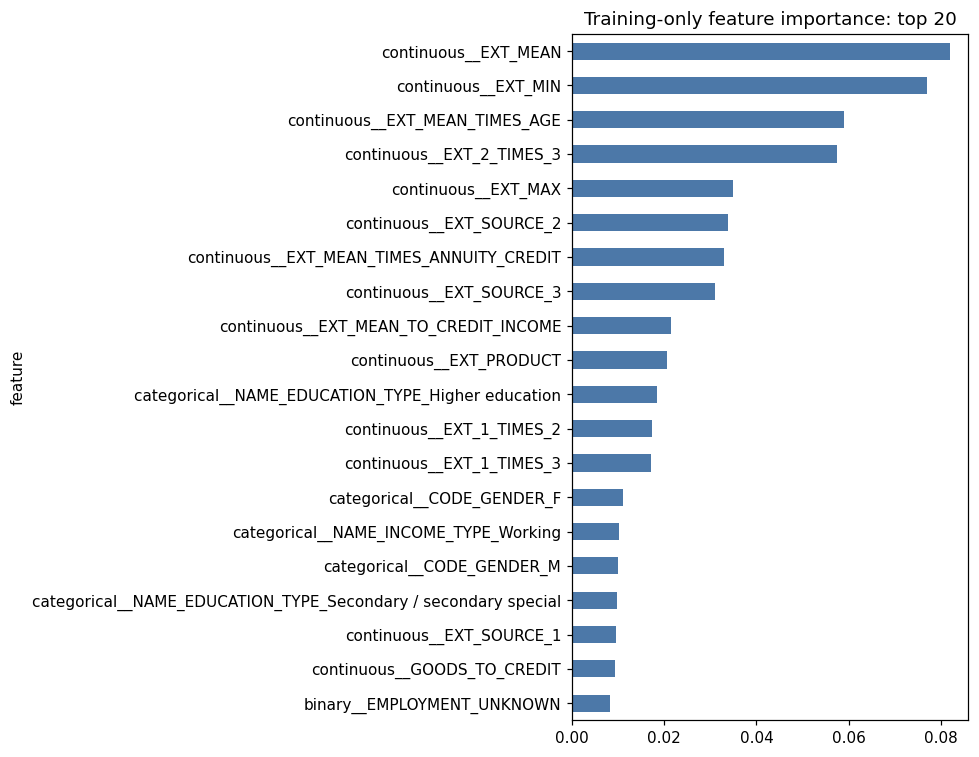

Restored completed train-fitted preprocessing and feature selection.


In [5]:
def fit_preprocessing(train_frame, validation_frame):
    numeric = train_frame.select_dtypes(include=['number', 'bool']).columns.tolist()
    categorical = train_frame.select_dtypes(include=['object', 'category']).columns.tolist()
    continuous = [c for c in numeric if train_frame[c].nunique() > 2]
    binary = [c for c in numeric if c not in continuous]
    continuous_pipe = Pipeline([
        ('impute', SimpleImputer(strategy='median', keep_empty_features=True)),
        ('quantile', QuantileTransformer(n_quantiles=512, output_distribution='normal',
                                         subsample=100_000, random_state=RANDOM_STATE)),
    ])
    category_pipe = Pipeline([
        ('impute', SimpleImputer(strategy='constant', fill_value='Missing')),
        ('encode', OneHotEncoder(handle_unknown='infrequent_if_exist', min_frequency=50,
                                 sparse_output=False, dtype=np.float32)),
    ])
    prep = ColumnTransformer([
        ('continuous', continuous_pipe, continuous),
        ('binary', SimpleImputer(strategy='most_frequent', keep_empty_features=True), binary),
        ('missing', MissingIndicator(features='all', error_on_new=False), numeric),
        ('categorical', category_pipe, categorical),
    ], sparse_threshold=0, n_jobs=1)
    a = np.clip(prep.fit_transform(train_frame), -4, 4).astype(np.float32)
    b = np.clip(prep.transform(validation_frame), -4, 4).astype(np.float32)
    names = prep.get_feature_names_out()
    variance = VarianceThreshold(threshold=0.0)
    a = variance.fit_transform(a)
    b = variance.transform(b)
    names = names[variance.get_support()]
    # Compare columns exactly after grouping by their byte hashes.
    import hashlib
    groups, unique = {}, []
    for j in range(a.shape[1]):
        key = hashlib.sha256(a[:, j].tobytes()).digest()
        prior = groups.setdefault(key, [])
        if not any(np.array_equal(a[:, j], a[:, k]) for k in prior):
            unique.append(j)
            prior.append(j)
    unique = np.asarray(unique)
    bundle = {'preprocessor': prep, 'variance': variance, 'unique': unique,
              'feature_names': names[unique]}
    a, b = np.ascontiguousarray(a[:, unique]), np.ascontiguousarray(b[:, unique])
    assert np.isfinite(a).all() and np.isfinite(b).all()
    return bundle, a, b

baseline_bundle, baseline_train, baseline_val = fit_preprocessing(
    engineer_features(train_raw, False), engineer_features(val_raw, False))
feature_bundle, full_train, full_val = fit_preprocessing(train_engineered, val_engineered)
print(f'Raw baseline inputs: {baseline_train.shape[1]}; engineered inputs: {full_train.shape[1]}')
ranker = ExtraTreesClassifier(n_estimators=64, max_depth=12, min_samples_leaf=20,
                              max_features='sqrt', n_jobs=1, random_state=RANDOM_STATE)
ranking_rows = np.arange(len(y_train))
if len(ranking_rows) > 100_000:
    ranking_rows, _ = train_test_split(ranking_rows, train_size=100_000,
                                      stratify=y_train, random_state=RANDOM_STATE)
ranker.fit(full_train[ranking_rows], y_train[ranking_rows])
importance = pd.DataFrame({
    'feature': feature_bundle['feature_names'], 'importance': ranker.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)
ranking = np.argsort(-ranker.feature_importances_)
feature_sets = {
    'all': np.arange(full_train.shape[1]),
    'top256': np.sort(ranking[:min(256, len(ranking))]),
    'top128': np.sort(ranking[:min(128, len(ranking))]),
}
importance.to_csv(ARTIFACT_DIR / 'feature_importance.csv', index=False)
joblib.dump({'baseline': baseline_bundle, 'engineered': feature_bundle,
             'feature_sets': feature_sets}, ARTIFACT_DIR / 'preprocessing.joblib')
display(importance.head(25))
fig, ax = plt.subplots(figsize=(9, 7))
importance.head(20).iloc[::-1].plot.barh(x='feature', y='importance', legend=False, ax=ax, color='#4C78A8')
ax.set_title('Training-only feature importance: top 20')
plt.tight_layout()
plt.show()
del ranker
gc.collect()


## 4. Train a regularized neural network and tune ROC AUC

The network combines a linear input-to-logit connection with a nonlinear
multilayer perceptron. Batch normalization, dropout, AdamW weight decay, and a
learning-rate scheduler control overfitting. Early stopping monitors validation
ROC AUC and **restores the best checkpoint**. Inputs receive light Gaussian
noise during training for regularization.

Unweighted binary cross-entropy is the main loss: class imbalance alone does
not require rebalancing when optimizing ranking. A modest positive-class
weight is included as an experiment. No oversampling crosses split boundaries.
The baseline uses the same training code and split, making its comparison with
engineered features useful.


In [6]:
class CreditNet(nn.Module):
    def __init__(self, input_dim, hidden=(128, 64), dropout=0.20, input_dropout=0.03):
        super().__init__()
        self.input_dropout = nn.Dropout(input_dropout)
        layers, width = [], input_dim
        for next_width in hidden:
            layers.extend([nn.Linear(width, next_width), nn.BatchNorm1d(next_width),
                           nn.SiLU(), nn.Dropout(dropout)])
            width = next_width
        layers.append(nn.Linear(width, 1))
        self.deep = nn.Sequential(*layers)
        self.linear = nn.Linear(input_dim, 1)
        nn.init.zeros_(self.linear.weight)
        nn.init.zeros_(self.linear.bias)

    def forward(self, x):
        return (self.deep(self.input_dropout(x)) + self.linear(x)).squeeze(1)

def make_model(config, input_dim):
    return CreditNet(input_dim, tuple(config['hidden']), config['dropout'],
                     config.get('input_dropout', 0.03)).to(DEVICE)

@torch.no_grad()
def predict_network(model, x, batch_size=8192):
    model.eval()
    values = []
    for start in range(0, len(x), batch_size):
        inputs = torch.as_tensor(x[start:start + batch_size], dtype=torch.float32, device=DEVICE)
        values.append(torch.sigmoid(model(inputs)).cpu().numpy())
    return np.concatenate(values)

def train_trial(config, x_train, x_validation, seed=42):
    seed_everything(seed)
    start = time.perf_counter()
    model = make_model(config, x_train.shape[1])
    # Initialize the overall intercept to the training prior.
    prior = float(y_train.mean())
    nn.init.constant_(model.linear.bias, math.log(prior / (1 - prior)))
    optimizer = torch.optim.AdamW(model.parameters(), lr=config.get('lr', 0.001),
                                   weight_decay=config.get('weight_decay', 0.01))
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=2, min_lr=2e-5)
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(config.get('pos_weight', 1.0), device=DEVICE))
    xt = torch.as_tensor(np.ascontiguousarray(x_train), dtype=torch.float32, device=DEVICE)
    yt = torch.as_tensor(y_train, dtype=torch.float32, device=DEVICE)
    best_auc, best_epoch, best_state, stale = -np.inf, 0, None, 0
    history = []
    for epoch in range(1, config.get('max_epochs', MAX_EPOCHS) + 1):
        model.train()
        order = torch.randperm(len(xt), device=DEVICE)
        loss_sum = 0.0
        for indices in order.split(BATCH_SIZE):
            if len(indices) < 2:
                continue
            xb, yb = xt[indices], yt[indices]
            noise = config.get('noise', 0.02)
            if noise:
                xb = xb + noise * torch.randn_like(xb)
            optimizer.zero_grad(set_to_none=True)
            loss = criterion(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            loss_sum += float(loss.detach()) * len(indices)
        pred = predict_network(model, x_validation)
        auc = roc_auc_score(y_val, pred)
        history.append({'epoch': epoch, 'train_loss': loss_sum / len(xt),
                        'val_auc': auc, 'lr': optimizer.param_groups[0]['lr']})
        scheduler.step(auc)
        material_improvement = auc > best_auc + 1e-5
        if auc > best_auc:
            best_auc, best_epoch = auc, epoch
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
        stale = 0 if material_improvement else stale + 1
        if epoch == 1 or epoch % 5 == 0:
            print(f"{config['name']} seed={seed} epoch={epoch:02d}: val AUC={auc:.6f}, best={best_auc:.6f}", flush=True)
        if stale >= PATIENCE:
            break
    model.load_state_dict(best_state)
    val_pred = predict_network(model, x_validation)
    elapsed = time.perf_counter() - start
    checkpoint_name = f"{config['name']}_seed{seed}.pt"
    torch.save({'state_dict': best_state, 'config': config, 'seed': seed,
                'input_dim': x_train.shape[1], 'best_epoch': best_epoch}, ARTIFACT_DIR / checkpoint_name)
    record = {'name': config['name'], 'feature_set': config['feature_set'], 'seed': seed,
              'val_auc': float(roc_auc_score(y_val, val_pred)), 'best_epoch': best_epoch,
              'epochs_run': epoch, 'seconds': round(elapsed, 1), 'checkpoint': checkpoint_name,
              'config': config.copy(), 'history': history, 'val_pred': val_pred}
    print(f"Finished {config['name']}: AUC={record['val_auc']:.6f}, epoch={best_epoch}, {elapsed:.1f}s", flush=True)
    del model, xt, yt, optimizer
    gc.collect()
    return record

def trial_arrays(feature_set):
    if feature_set == 'baseline':
        return baseline_train, baseline_val
    columns = feature_sets[feature_set]
    return np.ascontiguousarray(full_train[:, columns]), np.ascontiguousarray(full_val[:, columns])

TRIALS = [
    dict(name='raw_baseline', feature_set='baseline', hidden=[128, 64], dropout=0.20, weight_decay=0.01),
    dict(name='engineered_all', feature_set='all', hidden=[128, 64], dropout=0.20, weight_decay=0.01),
    dict(name='selected256', feature_set='top256', hidden=[128, 64], dropout=0.20, weight_decay=0.01),
    dict(name='selected128', feature_set='top128', hidden=[128, 64], dropout=0.20, weight_decay=0.01),
    dict(name='wide256', feature_set='top256', hidden=[256, 128, 64], dropout=0.30, weight_decay=0.02),
    dict(name='small256', feature_set='top256', hidden=[64, 32], dropout=0.15, weight_decay=0.02),
    dict(name='regularized_all', feature_set='all', hidden=[128, 64], dropout=0.35, input_dropout=0.08, weight_decay=0.03),
    dict(name='weighted256', feature_set='top256', hidden=[128, 64], dropout=0.25, weight_decay=0.02, pos_weight=2.0),
]
records = []
for config in TRIALS:
    records.append(train_trial(config, *trial_arrays(config['feature_set'])))

def leaderboard(records):
    return pd.DataFrame([{k: v for k, v in r.items() if k not in ['config', 'history', 'val_pred']}
                         for r in records]).sort_values('val_auc', ascending=False).reset_index(drop=True)

display(leaderboard(records))


raw_baseline seed=42 epoch=01: val AUC=0.735828, best=0.735828
raw_baseline seed=42 epoch=05: val AUC=0.744439, best=0.744769
raw_baseline seed=42 epoch=10: val AUC=0.748082, best=0.748461
raw_baseline seed=42 epoch=15: val AUC=0.748152, best=0.750593
raw_baseline seed=42 epoch=20: val AUC=0.749627, best=0.750593
Finished raw_baseline: AUC=0.750593, epoch=13, 114.7s
engineered_all seed=42 epoch=01: val AUC=0.746095, best=0.746095
engineered_all seed=42 epoch=05: val AUC=0.751743, best=0.752487
engineered_all seed=42 epoch=10: val AUC=0.754123, best=0.755850
engineered_all seed=42 epoch=15: val AUC=0.754708, best=0.755850
Finished engineered_all: AUC=0.755850, epoch=9, 96.9s
selected256 seed=42 epoch=01: val AUC=0.745104, best=0.745104
selected256 seed=42 epoch=05: val AUC=0.751102, best=0.751825
selected256 seed=42 epoch=10: val AUC=0.754741, best=0.754746
selected256 seed=42 epoch=15: val AUC=0.755260, best=0.755666
selected256 seed=42 epoch=20: val AUC=0.754839, best=0.755666
Finishe

,name,feature_set,seed,val_auc,best_epoch,epochs_run,seconds,checkpoint
0,selected128,top128,42,0.756586,15,22,101.6,selected128_seed42.pt
1,regularized_all,all,42,0.756475,19,26,169.7,regularized_all_seed42.pt
2,weighted256,top256,42,0.756192,11,18,101.2,weighted256_seed42.pt
3,engineered_all,all,42,0.755850,9,16,96.9,engineered_all_seed42.pt
4,selected256,top256,42,0.755666,13,20,140.6,selected256_seed42.pt
5,wide256,top256,42,0.755087,18,25,245.9,wide256_seed42.pt
6,small256,top256,42,0.754866,9,16,70.4,small256_seed42.pt
7,raw_baseline,baseline,42,0.750593,13,20,114.7,raw_baseline_seed42.pt


## 5. Reduce seed variance and choose the final ensemble on validation

Retrain the two strongest engineered configurations with two additional random
seeds each. Compare the strongest individual model with a small, predefined
set of equal-weight ensembles. Keep the best validation choice, including the
single model if averaging does not help. This validation score is optimistic
because it guided selection; the held-out test below is the final estimate.


In [7]:
top_configs = sorted([r for r in records if r['feature_set'] != 'baseline'],
                     key=lambda r: r['val_auc'], reverse=True)[:2]
for original in top_configs:
    for seed in [2026, 3407]:
        records.append(train_trial(original['config'], *trial_arrays(original['feature_set']), seed=seed))

best_single = max(records, key=lambda r: r['val_auc'])
ensemble_candidates = [('best_single', [best_single])]
for original in top_configs:
    members = [r for r in records if r['name'] == original['name']]
    ensemble_candidates.append((f"{original['name']}_3seeds", members))
both_names = {r['name'] for r in top_configs}
ensemble_candidates.append(('top_two_configs_6seeds', [r for r in records if r['name'] in both_names]))
engineered_records = sorted([r for r in records if r['feature_set'] != 'baseline'],
                            key=lambda r: r['val_auc'], reverse=True)
ensemble_candidates.append(('top3_individuals', engineered_records[:3]))
ensemble_candidates.append(('top5_individuals', engineered_records[:5]))
ensemble_scores = []
for name, members in ensemble_candidates:
    pred = np.mean([r['val_pred'] for r in members], axis=0)
    ensemble_scores.append({'candidate': name, 'models': len(members),
                            'val_auc': float(roc_auc_score(y_val, pred))})
ensemble_comparison = pd.DataFrame(ensemble_scores).sort_values('val_auc', ascending=False)
chosen_name = ensemble_comparison.iloc[0]['candidate']
chosen_records = dict(ensemble_candidates)[chosen_name]
final_val_pred = np.mean([r['val_pred'] for r in chosen_records], axis=0)
final_val_auc = roc_auc_score(y_val, final_val_pred)
display(leaderboard(records))
display(ensemble_comparison)
print(f'Frozen final choice: {chosen_name}, validation ROC AUC={final_val_auc:.6f}')
leaderboard(records).to_csv(ARTIFACT_DIR / 'validation_leaderboard.csv', index=False)
ensemble_comparison.to_csv(ARTIFACT_DIR / 'ensemble_comparison.csv', index=False)
np.savez_compressed(ARTIFACT_DIR / 'validation_predictions.npz', y=y_val,
                    **{f"{r['name']}_seed{r['seed']}": r['val_pred'] for r in records})


selected128 seed=2026 epoch=01: val AUC=0.747425, best=0.747425
selected128 seed=2026 epoch=05: val AUC=0.754230, best=0.754230
selected128 seed=2026 epoch=10: val AUC=0.756802, best=0.756802
selected128 seed=2026 epoch=15: val AUC=0.756804, best=0.757913
Finished selected128: AUC=0.757913, epoch=12, 80.8s
selected128 seed=3407 epoch=01: val AUC=0.746968, best=0.746968
selected128 seed=3407 epoch=05: val AUC=0.754429, best=0.754429
selected128 seed=3407 epoch=10: val AUC=0.754781, best=0.755644
selected128 seed=3407 epoch=15: val AUC=0.756662, best=0.756662
selected128 seed=3407 epoch=20: val AUC=0.756444, best=0.756744
selected128 seed=3407 epoch=25: val AUC=0.756061, best=0.756744
Finished selected128: AUC=0.756744, epoch=19, 120.1s
regularized_all seed=2026 epoch=01: val AUC=0.746372, best=0.746372
regularized_all seed=2026 epoch=05: val AUC=0.751363, best=0.751363
regularized_all seed=2026 epoch=10: val AUC=0.753618, best=0.753618
regularized_all seed=2026 epoch=15: val AUC=0.75504

,name,feature_set,seed,val_auc,best_epoch,epochs_run,seconds,checkpoint
0,selected128,top128,2026,0.757913,12,19,80.8,selected128_seed2026.pt
1,regularized_all,all,3407,0.757166,23,30,683.9,regularized_all_seed3407.pt
2,selected128,top128,3407,0.756744,19,26,120.1,selected128_seed3407.pt
3,selected128,top128,42,0.756586,15,22,101.6,selected128_seed42.pt
4,regularized_all,all,42,0.756475,19,26,169.7,regularized_all_seed42.pt
5,regularized_all,all,2026,0.756225,22,29,183.2,regularized_all_seed2026.pt
6,weighted256,top256,42,0.756192,11,18,101.2,weighted256_seed42.pt
7,engineered_all,all,42,0.755850,9,16,96.9,engineered_all_seed42.pt
8,selected256,top256,42,0.755666,13,20,140.6,selected256_seed42.pt
9,wide256,top256,42,0.755087,18,25,245.9,wide256_seed42.pt


,candidate,models,val_auc
4,top3_individuals,3,0.758932
5,top5_individuals,5,0.758866
3,top_two_configs_6seeds,6,0.758769
1,selected128_3seeds,3,0.758143
0,best_single,1,0.757913
2,regularized_all_3seeds,3,0.757278


Frozen final choice: top3_individuals, validation ROC AUC=0.758932


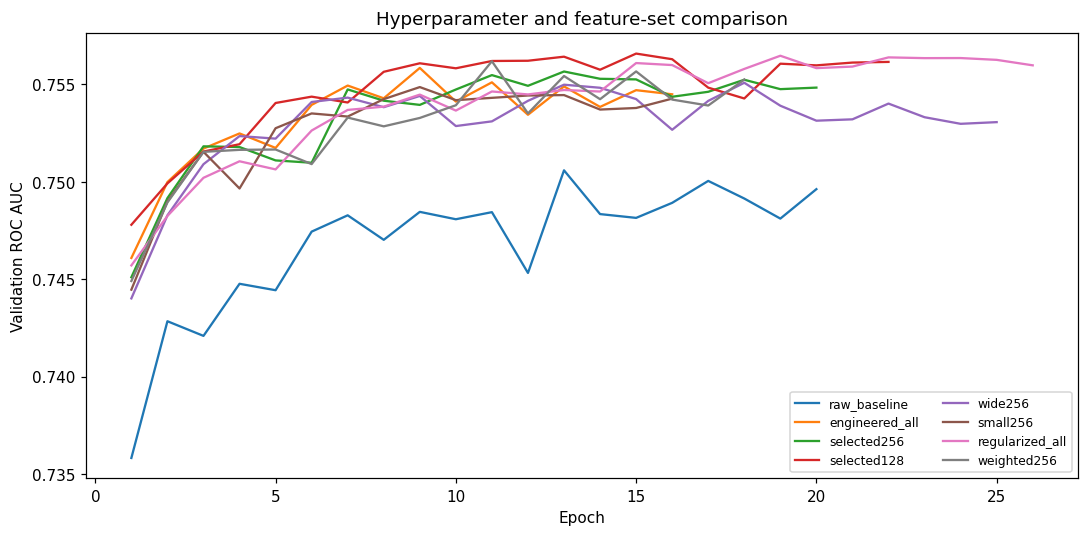

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
for record in records[:len(TRIALS)]:
    history = pd.DataFrame(record['history'])
    ax.plot(history['epoch'], history['val_auc'], label=record['name'])
ax.set(xlabel='Epoch', ylabel='Validation ROC AUC', title='Hyperparameter and feature-set comparison')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()


## 6. Final held-out test evaluation

All choices are now frozen. Evaluate the test once, report ROC AUC alongside
average precision and log loss, and bootstrap a 95% interval for test AUC.
The interval describes test-sample uncertainty conditional on the trained
models; it does not include training-seed or model-selection uncertainty.
A threshold of 0.5 is shown only for a diagnostic confusion matrix. Changing
that threshold does not improve ROC AUC.


{
  "selected_candidate": "top3_individuals",
  "ensemble_size": 3,
  "baseline_validation_auc": 0.7505930915034471,
  "validation_auc": 0.7589318463825598,
  "test_auc": 0.7607466760229028,
  "test_auc_95pct_interval": [
    0.7539137473136535,
    0.7674462868720187
  ],
  "test_average_precision": 0.24961527310463935,
  "test_log_loss": 0.24524302780628204,
  "test_positive_rate": 0.08072776937710356,
  "train_rows": 196806,
  "validation_rows": 49202,
  "test_rows": 61503,
  "raw_features": 120,
  "engineered_additions": 48,
  "processed_engineered_features": 325,
  "random_state": 42,
  "torch_version": "2.14.0+cpu"
}

Confusion matrix at threshold 0.5:
[[56458    80]
 [ 4864   101]]
              precision    recall  f1-score   support

           0     0.9207    0.9986    0.9581     56538
           1     0.5580    0.0203    0.0393      4965

    accuracy                         0.9196     61503
   macro avg     0.7393    0.5095    0.4987     61503
weighted avg     0.8914    0.9

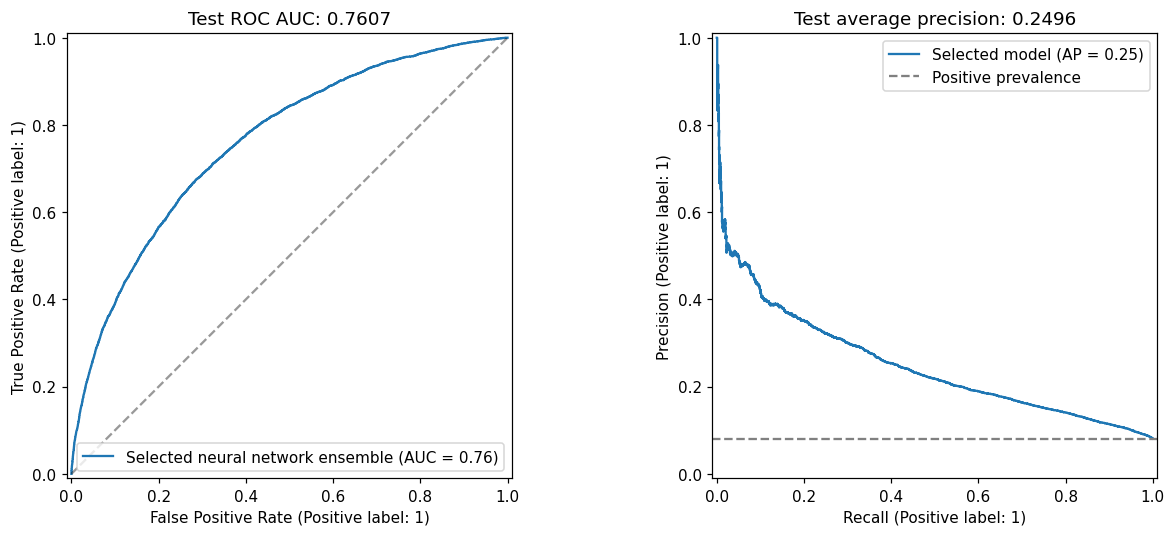

In [9]:
def transform_frame(bundle, frame):
    transformed = np.clip(bundle['preprocessor'].transform(frame), -4, 4).astype(np.float32)
    transformed = bundle['variance'].transform(transformed)[:, bundle['unique']]
    assert np.isfinite(transformed).all()
    return np.ascontiguousarray(transformed)

def predict_records(raw, members):
    predictions, transformed_cache = [], {}
    for record in members:
        is_baseline = record['feature_set'] == 'baseline'
        kind = 'baseline' if is_baseline else 'engineered'
        if kind not in transformed_cache:
            bundle = baseline_bundle if is_baseline else feature_bundle
            transformed_cache[kind] = transform_frame(bundle, engineer_features(raw, not is_baseline))
        x = transformed_cache[kind]
        if not is_baseline:
            x = np.ascontiguousarray(x[:, feature_sets[record['feature_set']]])
        checkpoint = torch.load(ARTIFACT_DIR / record['checkpoint'], map_location=DEVICE, weights_only=True)
        model = make_model(checkpoint['config'], checkpoint['input_dim'])
        model.load_state_dict(checkpoint['state_dict'])
        predictions.append(predict_network(model, x))
        del model
    return np.mean(predictions, axis=0)

test_raw = df.iloc[test_idx].drop(columns=['TARGET', 'SK_ID_CURR'])
y_test = df.iloc[test_idx]['TARGET'].to_numpy(dtype=np.int64)
test_pred = predict_records(test_raw, chosen_records)
test_auc = roc_auc_score(y_test, test_pred)
test_ap = average_precision_score(y_test, test_pred)

rng = np.random.default_rng(RANDOM_STATE)
negative = np.flatnonzero(y_test == 0)
positive = np.flatnonzero(y_test == 1)
bootstrap_auc = []
for _ in range(300):
    sample = np.concatenate([rng.choice(negative, len(negative), replace=True),
                             rng.choice(positive, len(positive), replace=True)])
    bootstrap_auc.append(roc_auc_score(y_test[sample], test_pred[sample]))
lower, upper = np.quantile(bootstrap_auc, [0.025, 0.975])
metrics = {
    'selected_candidate': chosen_name, 'ensemble_size': len(chosen_records),
    'baseline_validation_auc': records[0]['val_auc'],
    'validation_auc': float(final_val_auc), 'test_auc': float(test_auc),
    'test_auc_95pct_interval': [float(lower), float(upper)],
    'test_average_precision': float(test_ap),
    'test_log_loss': float(log_loss(y_test, test_pred)),
    'test_positive_rate': float(y_test.mean()),
    'train_rows': len(train_idx), 'validation_rows': len(val_idx), 'test_rows': len(test_idx),
    'raw_features': train_raw.shape[1], 'engineered_additions': len(new_features),
    'processed_engineered_features': full_train.shape[1],
    'random_state': RANDOM_STATE, 'torch_version': str(torch.__version__),
}
print(json.dumps(metrics, indent=2))
print('\nConfusion matrix at threshold 0.5:')
print(confusion_matrix(y_test, test_pred >= 0.5))
print(classification_report(y_test, test_pred >= 0.5, digits=4, zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
RocCurveDisplay.from_predictions(y_test, test_pred, name='Selected neural network ensemble', ax=axes[0])
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[0].set_title(f'Test ROC AUC: {test_auc:.4f}')
PrecisionRecallDisplay.from_predictions(y_test, test_pred, ax=axes[1], name='Selected model')
axes[1].axhline(y_test.mean(), linestyle='--', color='gray', label='Positive prevalence')
axes[1].set_title(f'Test average precision: {test_ap:.4f}')
axes[1].legend()
plt.tight_layout()
plt.show()


## 7. Save results and predict new applications

`nn1_artifacts/` contains the fitted preprocessing, training-only feature
importance, validation leaderboard, model checkpoints, split indices, metrics,
and held-out predictions. It is git-ignored because the files are generated.
To score new rows in this notebook, call `predict_applications(new_frame)`;
the frame must contain the original application input columns. Labels and IDs
are excluded automatically. The trained models retain the training split
used above so the reported test result matches these exact saved checkpoints.


In [10]:
manifest = {'metrics': metrics, 'models': [
    {k: r[k] for k in ['name', 'feature_set', 'seed', 'checkpoint', 'config', 'val_auc', 'best_epoch']}
    for r in chosen_records
]}
(ARTIFACT_DIR / 'metrics.json').write_text(json.dumps(metrics, indent=2), encoding='utf-8')
(ARTIFACT_DIR / 'model_manifest.json').write_text(json.dumps(manifest, indent=2), encoding='utf-8')
pd.DataFrame({'SK_ID_CURR': df.iloc[test_idx]['SK_ID_CURR'].to_numpy(),
              'TARGET': y_test, 'predicted_default_probability': test_pred}).to_csv(
                  ARTIFACT_DIR / 'test_predictions.csv', index=False)

def predict_applications(new_frame):
    probability = predict_records(new_frame, chosen_records)
    return pd.Series(probability, index=new_frame.index, name='predicted_default_probability')

# Inference checks: missing/unseen categories, finite values, and stable row ordering.
example = test_raw.head(8).copy()
assert np.allclose(predict_applications(example), test_pred[:8], atol=1e-6)
example.iloc[0, example.columns.get_loc('NAME_INCOME_TYPE')] = 'NEW_UNSEEN_CATEGORY'
example.iloc[1, example.columns.get_loc('AMT_INCOME_TOTAL')] = np.nan
example_predictions = predict_applications(example)
assert np.isfinite(example_predictions).all() and example_predictions.between(0, 1).all()
print(f'Saved artifacts to {ARTIFACT_DIR.resolve()}')
print('Inference checks passed, including missing values and unseen categories.')
display(predict_applications(test_raw.head()))


Saved artifacts to C:\Users\dilra\dataprocess\4401Project2\nn1_artifacts
Inference checks passed, including missing values and unseen categories.


nn1.ipynb:cell7:74: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


256571    0.073036
191493    0.041723
103497    0.150219
130646    0.079612
211898    0.097178
Name: predicted_default_probability, dtype: float32

## Interpretation and next experiments

Compare the raw baseline and engineered/selected runs in the validation
leaderboard rather than assuming additional features always help. Feature
selection may improve regularization and speed even if a full-feature model
wins. The final test AUC measures ranking on a random held-out sample from
this dataset, not performance on future applicants or a competition test set.

For a broader search, add configurations to `TRIALS` or use repeated stratified
cross-validation within the development data. Reserve a new holdout before
using the reported test result to make additional modeling choices. Additional
Home Credit history tables could support richer features, but are not present
in this project. Scores should be assessed for calibration, stability, and
subgroup performance before any real lending use.
